In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import ptft_replica_qk as rq


In [ ]:
# --- Replica PT+FT (standalone cell) ---
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import ptft_replica_qk as rq

# alpha grid + seeds
alphas = np.linspace(0.01, 0.5, 11)
seeds = [0]
lmdas = [0.0, -1e-3*0.99, 1e-3*0.99]
cs = [1e-3]
omegas = [1.0, 0.0]
gamma_reinits = [0.0, 1.0]

# PT+FT setups (Cartesian product across list-valued args)
df_replica_ptft = rq.build_ptft_curves_dataframe(
    rho_pt=[0.10],
    rho_ft=[0.10],   # change to your FT sparsities
    omega=omegas,   # change overlap list as desired
    c_pt=cs,  # change PT c list as desired
    lambda_pt=lmdas,  # change lambda list as desired
    gamma_reinit=gamma_reinits,      # change if you want reinit noise
    a_pt=1.0,
    alphas=alphas,
    mc=80_000,
    seed=seeds,
    gamma_ext=1e-6,
    tol=1e-6,
    max_iters=900,
    damp=0.25,
)


KeyboardInterrupt: 

In [21]:
replica_ptft_df = pd.read_csv('/home/na658/multi-task2/results/diagonal/replica_ptft/replica_ptft_sweep_master.csv')

In [8]:
replica_ptft_df

,rho_pt,rho_ft,omega,c_pt,lambda_pt,gamma_reinit,seed,alpha,mse_best,active_best,mse_fwd,mse_bwd,diff_db,fp_residual,mse_se,mse_rel_se,mse_se_db,reliability_score_db,rho_pt_emp,rho_ft_emp
0,0.1,0.1,1.0,0.001,0.00099,0.0,0,0.451,0.000012,0.999575,0.000012,0.000012,0.0,9.342153e-07,1.331496e-07,0.011000,0.047771,0.286505,0.101325,0.101325
1,0.1,0.1,1.0,0.001,0.00099,0.0,0,0.500,0.000008,0.999537,0.000008,0.000008,0.0,9.666735e-07,8.115367e-08,0.010202,0.044309,0.293732,0.101325,0.101325
2,0.1,0.1,1.0,0.001,0.00099,0.0,0,0.402,0.000019,0.999600,0.000019,0.000019,0.0,9.755335e-07,2.297187e-07,0.011845,0.051443,0.295684,0.101325,0.101325
3,0.1,0.1,1.0,0.001,0.00099,0.0,0,0.353,0.000034,0.999625,0.000034,0.000034,0.0,9.988335e-07,4.279021e-07,0.012749,0.055368,0.300777,0.101325,0.101325
4,0.1,0.1,0.0,0.001,0.00000,1.0,0,0.108,0.931908,0.999988,0.931908,0.931908,0.0,9.849537e-07,1.389691e-02,0.014912,0.064763,0.297750,0.098863,0.101325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,0.1,0.1,0.0,0.001,0.00099,1.0,0,0.010,1.017915,0.999988,1.017915,1.017915,0.0,9.216083e-07,1.754839e-02,0.017240,0.074870,0.283665,0.098863,0.101325
128,0.1,0.1,0.0,0.001,-0.00099,0.0,0,0.402,0.029403,0.996450,0.029403,0.029403,0.0,9.963883e-07,3.333025e-04,0.011336,0.049231,0.300245,0.098863,0.101325
129,0.1,0.1,0.0,0.001,-0.00099,1.0,0,0.500,0.246241,1.000000,0.246241,0.246241,0.0,9.630841e-07,2.213085e-03,0.008987,0.039032,0.292939,0.098863,0.101325
130,0.1,0.1,1.0,0.001,-0.00099,0.0,0,0.206,0.022573,0.993950,0.022573,0.022573,0.0,9.863980e-07,3.380424e-04,0.014976,0.065038,0.298066,0.101325,0.101325


In [13]:
replica_ptft_df.lambda_pt.value_counts()



lambda_pt
 0.00099    44
 0.00000    44
-0.00099    44
Name: count, dtype: int64

In [22]:
empirical_ptft_df = pd.read_csv('/home/na658/multi-task2/results/emp_ptft_sweep_c1e3_gamma0_alpha5_seed4_master.csv')
empirical_ptft_df2 = pd.read_csv('/home/na658/multi-task2/results/emp_ptft_sweep_c1e3_gamma1_alpha5_seed4_master.csv')

In [6]:
empirical_ptft_df.columns

Index(['a_pt', 'alpha', 'alpha_requested', 'beta0_l2', 'c_pt',
       'empirical_omega', 'epochs', 'final_active_frac', 'final_beta_l1',
       'final_beta_l2', 'final_beta_update_rate', 'final_epoch',
       'final_grad_norm', 'final_param_mse', 'final_test_pred_mse',
       'gamma_reinit', 'inp_dim', 'lambda_pt', 'log_every_n_epochs', 'lr',
       'lr_decay', 'lr_decay_interval', 'n_new', 'n_none', 'n_ov', 'n_ptonly',
       'n_test', 'n_train', 'no_tuning', 'omega', 'rho_ft', 'rho_pt',
       'save_folder', 'seed', 'setting', 'status', 'stop_beta_rate',
       'stop_grad_norm', 'stop_pred_mse', 'stop_reason', 'test_every_n_epochs',
       'threshold', 'wall_s'],
      dtype='object')

In [5]:
empirical_ptft_df

,a_pt,alpha,alpha_requested,beta0_l2,c_pt,empirical_omega,epochs,final_active_frac,final_beta_l1,final_beta_l2,...,seed,setting,status,stop_beta_rate,stop_grad_norm,stop_pred_mse,stop_reason,test_every_n_epochs,threshold,wall_s
0,1.0,0.0100,0.0100,0.0,0.001,1.0,5000000,0.9992,374.372947,21.582854,...,1,ptft,ok,0.0,0.0,NaN,train_pred_mse,5000,0.00001,5.182207
1,1.0,0.0100,0.0100,0.0,0.001,1.0,5000000,0.9996,383.408949,21.533904,...,0,ptft,ok,0.0,0.0,NaN,train_pred_mse,5000,0.00001,5.389863
2,1.0,0.0100,0.0100,0.0,0.001,0.0,5000000,0.9998,406.777589,24.708797,...,3,ptft,ok,0.0,0.0,NaN,train_pred_mse,5000,0.00001,4.733887
3,1.0,0.0100,0.0100,0.0,0.001,0.0,5000000,0.9996,384.753096,21.600952,...,0,ptft,ok,0.0,0.0,NaN,train_pred_mse,5000,0.00001,4.959292
4,1.0,0.0100,0.0100,0.0,0.001,1.0,5000000,0.9990,367.633275,21.740666,...,0,ptft,ok,0.0,0.0,NaN,train_pred_mse,5000,0.00001,6.822206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113,1.0,0.2000,0.2000,0.0,0.001,1.0,5000000,0.9944,1168.743898,63.647673,...,1,ptft,ok,0.0,0.0,NaN,train_pred_mse,5000,0.00001,1138.387860
114,1.0,0.2000,0.2000,0.0,0.001,0.0,5000000,0.9948,1153.107938,46.736130,...,1,ptft,ok,0.0,0.0,NaN,train_pred_mse,5000,0.00001,1140.893227
115,1.0,0.1524,0.1525,0.0,0.001,1.0,5000000,0.9930,1082.873659,57.476709,...,2,ptft,ok,0.0,0.0,NaN,train_pred_mse,5000,0.00001,1154.055096
116,1.0,0.2000,0.2000,0.0,0.001,0.0,5000000,0.9962,1161.935892,44.782878,...,2,ptft,ok,0.0,0.0,NaN,train_pred_mse,5000,0.00001,1220.388726


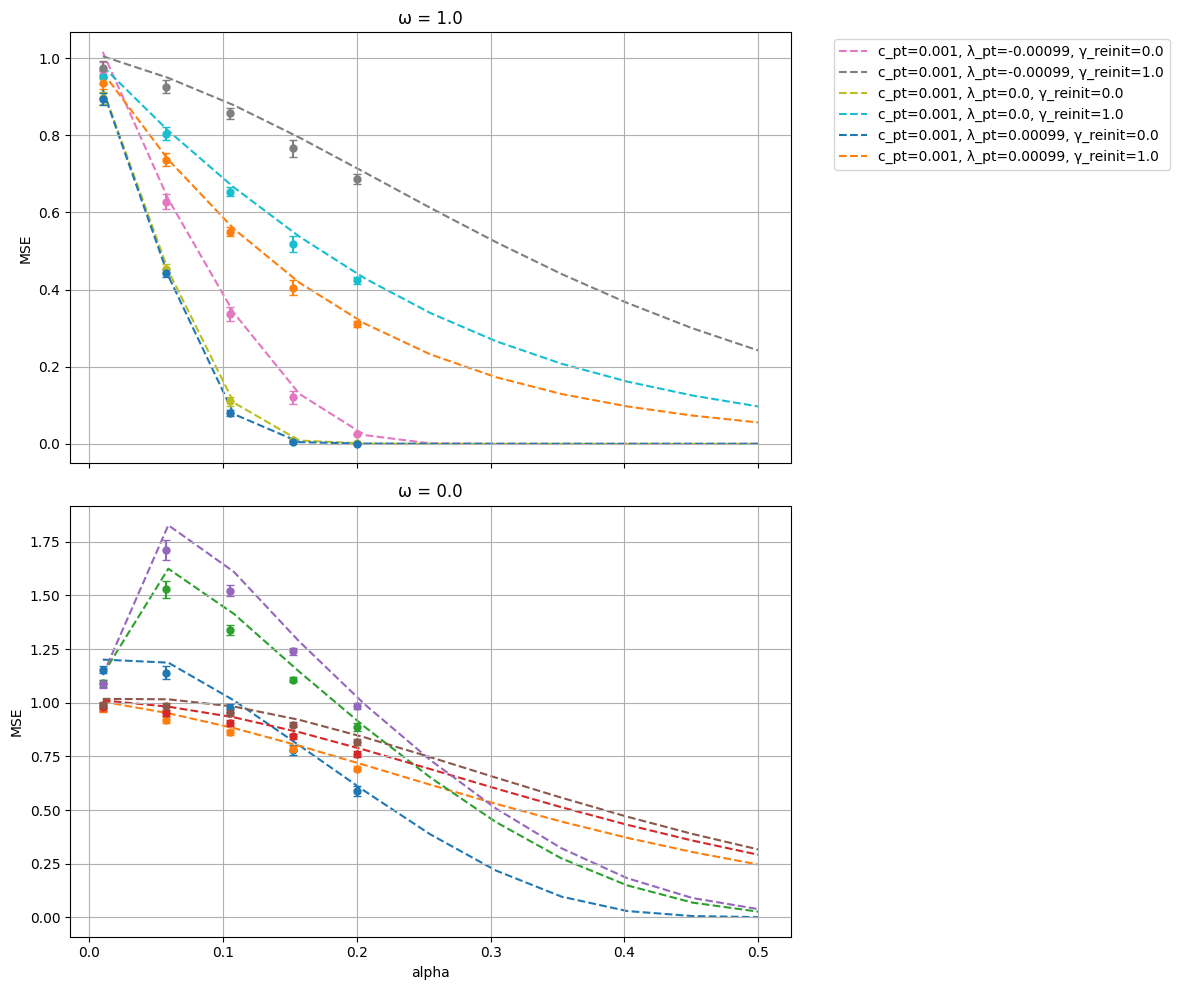

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Config ----------------
curve_df = replica_ptft_df.copy()
emp_df   = empirical_ptft_df.copy()
emp_df2  = empirical_ptft_df2.copy()

curve_x = "alpha"
curve_y = "mse_best"

emp_x = "alpha"
emp_y = "final_param_mse"

group_cols = ["omega", "c_pt", "lambda_pt", "gamma_reinit"]

# If needed (uncomment if names differ)
# emp_df = emp_df.rename(columns={"empirical_omega": "omega"})


# ---------------- Helpers ----------------
def se(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) <= 1:
        return np.nan
    return np.std(x, ddof=1) / np.sqrt(len(x))


# ---------------- Color mapping (per setup) ----------------
all_setups = sorted(
    set(map(tuple, curve_df[group_cols].drop_duplicates().to_numpy()))
    | set(map(tuple, emp_df[group_cols].drop_duplicates().to_numpy()))
)

cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
setup_to_color = {
    setup: cycle[i % len(cycle)]
    for i, setup in enumerate(all_setups)
}


# ---------------- Aggregate empirical data ----------------
emp_summary = (
    emp_df.groupby(group_cols + [emp_x])[emp_y]
    .agg(mean="mean", se=se)
    .reset_index()
)

emp_summary2 = (
    emp_df2.groupby(group_cols + [emp_x])[emp_y]
    .agg(mean="mean", se=se)
    .reset_index()
)


# ---------------- Plot ----------------
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for ax, omega_val in zip(axes, [1.0, 0.0]):

    # ---- Curves ----
    for setup, g in curve_df[curve_df["omega"] == omega_val].groupby(group_cols):
        g = g.sort_values(curve_x)
        ax.plot(
            g[curve_x],
            g[curve_y],
            linestyle="--",
            color=setup_to_color[setup],
            label=f"c_pt={setup[1]}, λ_pt={setup[2]}, γ_reinit={setup[3]}",
            zorder=1,
        )

    # ---- Empirical points ----
    for setup, g in emp_summary[emp_summary["omega"] == omega_val].groupby(group_cols):
        g = g.sort_values(emp_x)
        ax.errorbar(
            g[emp_x],
            g["mean"],
            yerr=g["se"],
            fmt="o",
            linestyle="none",
            color=setup_to_color[setup],
            capsize=3,
            markersize=5,
            zorder=3,
        )

    for setup, g in emp_summary2[emp_summary2["omega"] == omega_val].groupby(group_cols):
        g = g.sort_values(emp_x)
        ax.errorbar(
            g[emp_x],
            g["mean"],
            yerr=g["se"],
            fmt="o",
            linestyle="none",
            color=setup_to_color[setup],
            capsize=3,
            markersize=5,
            zorder=3,
        )
    

    ax.set_title(f"ω = {omega_val}")
    ax.set_ylabel("MSE")
    ax.grid(True)

axes[-1].set_xlabel("alpha")

axes[0].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
fig.tight_layout()
plt.show()

In [ ]:
emp_df = pd.read_csv('')

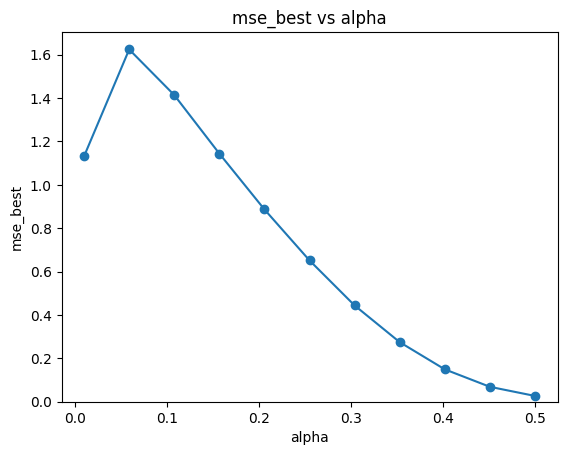

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_replica_ptft['alpha'], df_replica_ptft['mse_best'], marker='o')
plt.xlabel('alpha')
plt.ylabel('mse_best')
plt.title('mse_best vs alpha')
plt.ylim(bottom=0.0)
plt.show()

In [ ]:
# --- Empirical PT+FT (standalone cell) ---
from pathlib import Path
import sys

# make repo imports work from anywhere
p = Path.cwd().resolve()
for _ in range(12):
    if (p / ".git").exists():
        sys.path.insert(0, str(p))
        break
    p = p.parent

import numpy as np
import pandas as pd
import ptft_empirical_finetune_df as emp

alphas = np.linspace(0.01, 0.5, 11)
seeds = [0]
lmdas = [0.0]
cs = [1e-3]
omegas = [0.0]
gamma_reinits = [0.0]

df_empirical_ptft = emp.build_ptft_finetune_curves_dataframe(
    rho_pt=[0.10],
    rho_ft=[0.10],
    omega=omegas,
    a_pt=1.0,
    c_pt=cs,
    lambda_pt=lmdas,
    gamma_reinit=gamma_reinits,
    alphas=alphas.tolist(),
    inp_dim=5000,
    n_test=10_000,
    seeds=seeds,
    lr=0.5,
    epochs=5_000_000,
    test_every_n_epochs=5000,   # eval/stopping cadence
    log_every_n_epochs=50000,   # log cadence
    no_tuning=True,
    threshold=1e-5,
)


Starting training loop (max 5000000 epochs, threshold=1.00e-05)...
[invariants@init] c_emp: mean=1.019000e-01, min=2.000000e-03, max=1.001000e+00; lmda_pos: mean=1.019000e-01, min=2.000000e-03, max=1.001000e+00; lmda_neg: mean=1.019000e-01, min=2.000000e-03, max=1.001000e+00
Epoch      0 (0.0%): Train pred MSE = 8.930399e-01, Test pred MSE = 1.033539e+00, Param MSE = 1.026407e+00, Grad norm = 1.218450e-01, Beta update rate = inf, c_emp_max_dev = 3.257e-05, lam_pos_max_dev = 3.257e-05, lam_pos_neg_max_gap = 0.000e+00

Training completed at epoch 5000
Stop reason: train_pred_mse
Final Train pred MSE = 1.016313e-13
Final Test pred MSE = 1.126366e+00
Final Param MSE = 1.121147e+00
Final Grad norm = 3.275512e-08
Final Beta update rate = 2.544455e+02
Success flag: True (train_pred_mse < 1.00e-05)

Starting training loop (max 5000000 epochs, threshold=1.00e-05)...
[invariants@init] c_emp: mean=1.019000e-01, min=2.000000e-03, max=1.001000e+00; lmda_pos: mean=1.019000e-01, min=2.000000e-03, ma

In [2]:
df_empirical_ptft

,status,setting,seed,inp_dim,alpha_requested,n_train,alpha,n_test,c_pt,lambda_pt,...,final_beta_l1,final_beta_l2,final_active_frac,beta0_l2,empirical_omega,n_ov,n_new,n_ptonly,n_none,wall_s
0,ok,ptft,0,5000,0.010,50,0.010,10000,0.001,0.0,...,470.057180,32.206073,0.9998,0.0,0.0,0,500,475,4025,5.893152
1,ok,ptft,0,5000,0.055,275,0.055,10000,0.001,0.0,...,1227.185084,74.213505,1.0000,0.0,0.0,0,500,475,4025,23.111113
2,ok,ptft,0,5000,0.100,500,0.100,10000,0.001,0.0,...,1488.425839,74.696546,1.0000,0.0,0.0,0,500,475,4025,66.458899


In [2]:
df_empirical_ptft = pd.read_csv('/home/na658/multi-task2/results/emp_ptft_omega0_c1e3_lam0_master.csv')

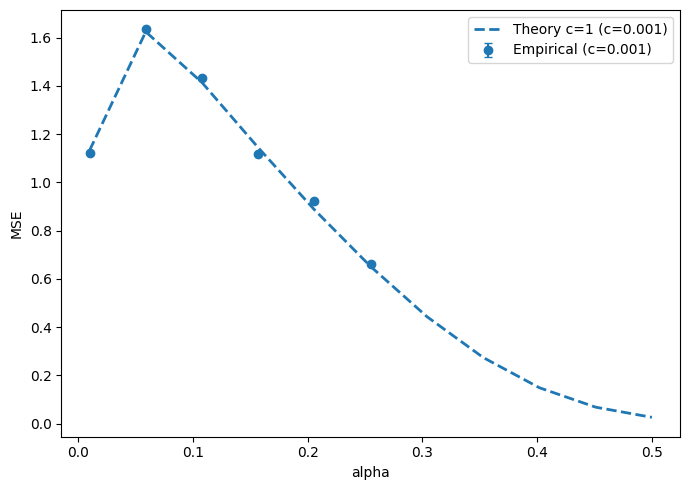

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

# ---------- empirical summary ----------
emp_summary = (
    df_empirical_ptft
    .groupby(['alpha', 'c_pt'])['final_param_mse']
    .agg(['mean', 'sem'])
    .reset_index()
)

# color cycle
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, c_pt in enumerate(sorted(emp_summary['c_pt'].unique())):
    color = colors[i % len(colors)]

    # empirical: points + SEM
    df_emp = emp_summary[emp_summary['c_pt'] == c_pt]
    plt.errorbar(
        df_emp['alpha'],
        df_emp['mean'],
        yerr=df_emp['sem'],
        fmt='o',
        capsize=3,
        linestyle='none',
        color=color,
        label=f'Empirical (c={c_pt})'
    )

    df_th = df_replica_ptft[df_replica_ptft['c_pt'] == c_pt]
    if not df_th.empty:
        plt.plot(
            df_th['alpha'],
            df_th['mse_best'],
            linestyle='--',
            linewidth=2,
            color=color,
            label=f'Theory c=1 (c={c_pt})'
        )


plt.xlabel('alpha')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()